# **[프로젝트] Mini BERT 만들기**

**프로젝트 목표**

*   학습이 잘되는 것을 무엇으로 확인해야 되는가?
    *   Pretraining Model은 Loss가 줄어들지 않는 이유는 무엇일까?
    *   정량적 지표와 정성적 지표로 학습이 잘되는 것을 확인하고 성능을 확인하기에 충분한가?

*   반드시 말(출력)을 잘하는 모델을 만들어야 되나?
    *   구현한 모델은 무엇을 잘하는지 알아보자.

*  제한된 상황에서의 경량화 모델을 어떻게 효율적으로 만들까?



**0. 실행 전 준비**

In [ ]:
# Colab 전용 패키지 설치
# 이미 설치되어 있더라도 문제 없이 재실행 가능
%pip -q install sentencepiece bert-score scikit-learn tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
import os
import re
import gc
import json
import math
import time
import zipfile
import random
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Any, Tuple, Iterator, Optional

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sentencepiece as spm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [ ]:
class JsonConfig(dict):
    """dict처럼 쓰면서 attribute 접근도 가능한 간단한 config 유틸리티"""
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(key)

    def __setattr__(self, key, value):
        self[key] = value

    def save_json(self, path):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self, f, ensure_ascii=False, indent=2)

    @classmethod
    def load_json(cls, path):
        with open(path, "r", encoding="utf-8") as f:
            return cls(json.load(f))


CFG = JsonConfig({
    # 경로
    "BASE_DIR": "/content/mini_bert_project",
    "TOKENIZER_PREFIX": "spm_bert_ko_8k",
    "DATASET_DIR": "pretrain_memmap",
    "MODEL_DIR": "artifacts",

    # 데이터
    "KOWIKI_FILENAME": "kowiki.txt",
    "KOWIKI_PATH": "",                # txt 지정 (자동 탐색)
    "KOWIKI_ZIP_FILENAME": "kowiki.txt.zip",
    "KOWIKI_ZIP_PATH": "",            # zip 지정 (/content 아래에서 자동 탐색)
    "KOWIKI_EXTRACT_DIR": "/content/mini_bert_project/extracted_kowiki",
    "MAX_DOCS": 12000,                # Colab 기본값
    "MIN_SENT_LEN_CHARS": 5,
    "MAX_SEQ_LEN": 128,
    "MAX_TRAIN_EXAMPLES": 25000,
    "PREVIEW_JSON_ROWS": 200,

    # tokenizer
    "VOCAB_SIZE": 8000,
    "CHAR_COVERAGE": 0.9995,
    "SP_MODEL_TYPE": "unigram",

    # masking
    "MLM_PROB": 0.15,
    "MASK_REPLACE_PROB": 0.80,
    "RANDOM_REPLACE_PROB": 0.10,
    # 나머지 0.10은 원래 토큰 유지

    # model (약 1M params 목표)
    "HIDDEN_SIZE": 80,
    "NUM_HIDDEN_LAYERS": 4,
    "NUM_ATTENTION_HEADS": 4,
    "INTERMEDIATE_SIZE": 320,
    "HIDDEN_DROPOUT_PROB": 0.1,
    "ATTN_DROPOUT_PROB": 0.1,
    "MAX_POSITION_EMBEDDINGS": 128,
    "TYPE_VOCAB_SIZE": 2,
    "INITIALIZER_RANGE": 0.02,

    # train
    "BATCH_SIZE": 64 if torch.cuda.is_available() else 16,
    "NUM_EPOCHS": 10,
    "LEARNING_RATE": 5e-4,
    "WEIGHT_DECAY": 0.01,
    "WARMUP_RATIO": 0.1,
    "GRAD_CLIP_NORM": 1.0,
    "NUM_WORKERS": 2,
    "USE_AMP": True if torch.cuda.is_available() else False,
    "LOG_EVERY": 100,

    # eval
    "VAL_RATIO": 0.1,
    "BERTSCORE_MODEL": "xlm-roberta-base",
    "BERTSCORE_MAX_SAMPLES": 128,
})

BASE_DIR = Path(CFG.BASE_DIR)
BASE_DIR.mkdir(parents=True, exist_ok=True)
(Path(BASE_DIR / CFG.DATASET_DIR)).mkdir(parents=True, exist_ok=True)
(Path(BASE_DIR / CFG.MODEL_DIR)).mkdir(parents=True, exist_ok=True)

CFG_PATH = BASE_DIR / "experiment_config.json"
CFG.save_json(CFG_PATH)
print("Saved config to:", CFG_PATH)
print(json.dumps(CFG, ensure_ascii=False, indent=2))

Saved config to: /content/mini_bert_project/experiment_config.json
{
  "BASE_DIR": "/content/mini_bert_project",
  "TOKENIZER_PREFIX": "spm_bert_ko_8k",
  "DATASET_DIR": "pretrain_memmap",
  "MODEL_DIR": "artifacts",
  "KOWIKI_FILENAME": "kowiki.txt",
  "KOWIKI_PATH": "",
  "KOWIKI_ZIP_FILENAME": "kowiki.txt.zip",
  "KOWIKI_ZIP_PATH": "",
  "KOWIKI_EXTRACT_DIR": "/content/mini_bert_project/extracted_kowiki",
  "MAX_DOCS": 12000,
  "MIN_SENT_LEN_CHARS": 5,
  "MAX_SEQ_LEN": 128,
  "MAX_TRAIN_EXAMPLES": 25000,
  "PREVIEW_JSON_ROWS": 200,
  "VOCAB_SIZE": 8000,
  "CHAR_COVERAGE": 0.9995,
  "SP_MODEL_TYPE": "unigram",
  "MLM_PROB": 0.15,
  "MASK_REPLACE_PROB": 0.8,
  "RANDOM_REPLACE_PROB": 0.1,
  "HIDDEN_SIZE": 80,
  "NUM_HIDDEN_LAYERS": 4,
  "NUM_ATTENTION_HEADS": 4,
  "INTERMEDIATE_SIZE": 320,
  "HIDDEN_DROPOUT_PROB": 0.1,
  "ATTN_DROPOUT_PROB": 0.1,
  "MAX_POSITION_EMBEDDINGS": 128,
  "TYPE_VOCAB_SIZE": 2,
  "INITIALIZER_RANGE": 0.02,
  "BATCH_SIZE": 64,
  "NUM_EPOCHS": 10,
  "LEARNING_RA

**1. `kowiki.txt.zip` 자동 압축 해제 + 문서 로딩 및 문장 분리**

In [ ]:
SPECIAL_TOKENS = {
    "PAD": "[PAD]",
    "UNK": "[UNK]",
    "CLS": "[CLS]",
    "SEP": "[SEP]",
    "MASK": "[MASK]",
}

def normalize_text(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    text = text.replace("\u200b", " ").replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def split_into_sentences(text: str, min_chars: int = 5) -> List[str]:
    text = normalize_text(text)
    if not text:
        return []

    # 줄바꿈, 문장부호를 기준으로 1차 분리
    parts = re.split(r"(?:\n+)|(?<=[\.\!\?\…])\s+", text)

    # 너무 긴 chunk는 한국어 종결 형태 일부를 기준으로 추가 분리
    refined = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        if len(p) > 300:
            subparts = re.split(r"(?<=다\.)\s+|(?<=요\.)\s+|(?<=죠\.)\s+|(?<=니다\.)\s+", p)
            refined.extend([s.strip() for s in subparts if s and len(s.strip()) >= min_chars])
        else:
            refined.append(p)

    refined = [s for s in refined if len(s) >= min_chars]
    return refined

def _existing_file_candidates(filename: str, explicit_path: str = "") -> List[Path]:
    candidates = []
    candidate_strings = [
        explicit_path,
        f"/content/{filename}",
        f"/content/drive/MyDrive/{filename}",
        str(BASE_DIR / filename),
        filename,
    ]
    seen = set()
    for cand in candidate_strings:
        if not cand:
            continue
        p = Path(cand)
        key = str(p)
        if key in seen:
            continue
        seen.add(key)
        if p.exists() and p.is_file():
            candidates.append(p.resolve())

    for root_dir in [Path("/content"), BASE_DIR]:
        if root_dir.exists():
            for p in root_dir.rglob(filename):
                if p.is_file():
                    rp = p.resolve()
                    if str(rp) not in seen:
                        seen.add(str(rp))
                        candidates.append(rp)
    return candidates

def choose_largest_file(paths: List[Path]) -> Optional[Path]:
    if not paths:
        return None
    return max(paths, key=lambda p: (p.stat().st_size, p.stat().st_mtime))

def find_kowiki_sources() -> Dict[str, Any]:
    txt_candidates = _existing_file_candidates(CFG.KOWIKI_FILENAME, CFG.KOWIKI_PATH)
    zip_candidates = _existing_file_candidates(CFG.KOWIKI_ZIP_FILENAME, CFG.KOWIKI_ZIP_PATH)

    return {
        "txt_candidates": txt_candidates,
        "zip_candidates": zip_candidates,
        "txt": choose_largest_file(txt_candidates),
        "zip": choose_largest_file(zip_candidates),
    }

def extract_kowiki_from_zip(zip_path: Path, extract_dir: Path) -> Path:
    extract_dir.mkdir(parents=True, exist_ok=True)

    existing_txts = list(extract_dir.rglob(CFG.KOWIKI_FILENAME))
    zip_mtime = zip_path.stat().st_mtime
    need_extract = True
    if existing_txts:
        newest_txt_mtime = max(p.stat().st_mtime for p in existing_txts)
        if newest_txt_mtime >= zip_mtime:
            need_extract = False

    if need_extract:
        print(f"Extracting zip: {zip_path} -> {extract_dir}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
    else:
        print("이미 압축 해제된 파일을 재사용합니다:", extract_dir)

    txt_candidates = list(extract_dir.rglob(CFG.KOWIKI_FILENAME))
    txt_path = choose_largest_file(txt_candidates)
    if txt_path is None:
        raise FileNotFoundError(
            f"압축은 풀었지만 {CFG.KOWIKI_FILENAME} 파일을 찾지 못했습니다. zip 내부 구조를 확인하세요."
        )
    return txt_path.resolve()

def ensure_kowiki_txt_available() -> Tuple[Path, Optional[Path], str]:
    sources = find_kowiki_sources()
    zip_path = sources["zip"]
    txt_path = sources["txt"]

    print("Detected zip candidates:")
    for p in sources["zip_candidates"][:10]:
        print(" -", p)
    print("Detected txt candidates:")
    for p in sources["txt_candidates"][:10]:
        print(" -", p)

    if zip_path is not None:
        resolved_txt = extract_kowiki_from_zip(zip_path, Path(CFG.KOWIKI_EXTRACT_DIR))
        return resolved_txt, zip_path.resolve(), "zip"

    if txt_path is not None:
        return txt_path.resolve(), None, "txt"

    raise FileNotFoundError(
        "kowiki.txt.zip 또는 kowiki.txt 파일을 찾지 못했습니다.\n"
        "Colab 왼쪽 파일 패널에 업로드하거나 /content 에 복사한 뒤 다시 실행하세요.\n"
        f"기본 탐색 파일명: {CFG.KOWIKI_ZIP_FILENAME}, {CFG.KOWIKI_FILENAME}"
    )

def iter_kowiki_documents(txt_path: Path) -> Iterator[Dict[str, str]]:
    """
    지원 포맷
    1) WikiExtractor 형식: <doc ... title="..."> ... </doc>
    2) 빈 줄(blank line) 기준 문서 분리
    3) 일반 줄 단위 텍스트 (빈 줄이 거의 없으면 덩어리 단위로 이어 붙임)
    """
    in_doc = False
    current_title = ""
    current_lines: List[str] = []
    saw_doc_tag = False

    def finalize(lines: List[str], title: str = "") -> Optional[Dict[str, str]]:
        lines = [normalize_text(x) for x in lines if normalize_text(x)]
        if not lines:
            return None

        text = "\n".join(lines).strip()
        if not text:
            return None

        title_clean = normalize_text(title)

        # WikiExtractor는 제목이 본문 첫 줄에 반복되는 경우가 많음
        if title_clean and lines and normalize_text(lines[0]) == title_clean:
            text = "\n".join(lines[1:]).strip() or text

        return {
            "title": title_clean,
            "text": text,
        }

    with open(txt_path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")
            stripped = line.strip()

            if stripped.startswith("<doc"):
                saw_doc_tag = True
                in_doc = True
                current_lines = []
                m = re.search(r'title="([^"]+)"', stripped)
                current_title = normalize_text(m.group(1)) if m else ""
                continue

            if stripped.startswith("</doc>"):
                doc = finalize(current_lines, current_title)
                if doc is not None:
                    yield doc
                in_doc = False
                current_title = ""
                current_lines = []
                continue

            if saw_doc_tag:
                if in_doc:
                    current_lines.append(line)
                continue

            # doc tag가 없는 일반 txt 처리: 빈 줄을 문서 경계로 사용
            if stripped == "":
                doc = finalize(current_lines, current_title)
                if doc is not None:
                    yield doc
                current_title = ""
                current_lines = []
            else:
                current_lines.append(line)

    # 파일 끝 처리
    if current_lines:
        doc = finalize(current_lines, current_title)
        if doc is not None:
            yield doc

def load_kowiki_documents(txt_path: Path, max_docs: int = 12000) -> List[Dict[str, Any]]:
    docs = []

    iterator = iter_kowiki_documents(txt_path)
    for doc in tqdm(iterator, total=max_docs, desc="Collecting kowiki docs"):
        title = normalize_text(doc.get("title", ""))
        text = doc.get("text", "")
        sentences = split_into_sentences(text, min_chars=CFG.MIN_SENT_LEN_CHARS)

        # NSP를 위해 문장이 최소 2개 이상 필요
        if len(sentences) < 2:
            continue

        docs.append({
            "title": title,
            "sentences": sentences,
        })

        if len(docs) >= max_docs:
            break

    return docs

KOWIKI_PATH, KOWIKI_ZIP_PATH, KOWIKI_SOURCE_KIND = ensure_kowiki_txt_available()
print("Resolved source kind:", KOWIKI_SOURCE_KIND)
print("Resolved txt path:", KOWIKI_PATH)
if KOWIKI_ZIP_PATH is not None:
    print("Resolved zip path:", KOWIKI_ZIP_PATH)

docs = load_kowiki_documents(KOWIKI_PATH, CFG.MAX_DOCS)
print(f"Loaded usable docs: {len(docs):,}")
if not docs:
    raise RuntimeError("사용 가능한 문서가 없습니다. kowiki.txt 형식과 내용이 올바른지 확인하세요.")
print("Sample title:", docs[0]["title"])
print("Sample sentences:", docs[0]["sentences"][:3])


Detected zip candidates:
 - /content/kowiki.txt.zip
 - /content/kowiki.txt.zip
Detected txt candidates:
Extracting zip: /content/kowiki.txt.zip -> /content/mini_bert_project/extracted_kowiki
Resolved source kind: zip
Resolved txt path: /content/mini_bert_project/extracted_kowiki/kowiki.txt
Resolved zip path: /content/kowiki.txt.zip


Loaded usable docs: 12,000
Sample title: 
Sample sentences: ['지미 카터 제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.', '지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.', '조지아 공과대학교를 졸업하였다.']


**2. SentencePiece tokenizer 학습**

*   vocab_size=8000
*   source=`kowiki.txt.zip` → `kowiki.txt`
*   BERT 주요 특수토큰 `[PAD] [UNK] [CLS] [SEP] [MASK]` 반영  




In [ ]:
tokenizer_input_path = BASE_DIR / "tokenizer_corpus.txt"
sp_prefix = str(BASE_DIR / CFG.TOKENIZER_PREFIX)
sp_model_path = BASE_DIR / f"{CFG.TOKENIZER_PREFIX}.model"
sp_vocab_path = BASE_DIR / f"{CFG.TOKENIZER_PREFIX}.vocab"

# SentencePiece 학습용 말뭉치 파일 생성
with open(tokenizer_input_path, "w", encoding="utf-8") as f:
    for doc in tqdm(docs, desc="Writing tokenizer corpus"):
        for sent in doc["sentences"]:
            sent = normalize_text(sent)
            if sent:
                f.write(sent + "\n")

if not sp_model_path.exists():
    spm.SentencePieceTrainer.Train(
        input=str(tokenizer_input_path),
        model_prefix=sp_prefix,
        model_type=CFG.SP_MODEL_TYPE,
        vocab_size=CFG.VOCAB_SIZE,
        character_coverage=CFG.CHAR_COVERAGE,
        input_sentence_size=1_000_000,
        shuffle_input_sentence=True,
        train_extremely_large_corpus=True,
        pad_id=0,
        unk_id=1,
        bos_id=-1,
        eos_id=-1,
        pad_piece=SPECIAL_TOKENS["PAD"],
        unk_piece=SPECIAL_TOKENS["UNK"],
        user_defined_symbols=",".join([
            SPECIAL_TOKENS["CLS"],
            SPECIAL_TOKENS["SEP"],
            SPECIAL_TOKENS["MASK"],
        ]),
    )
else:
    print("기존 SentencePiece 모델을 재사용합니다. 새 코퍼스로 다시 학습하려면 기존 .model/.vocab 파일을 삭제하세요.")

print("SentencePiece model:", sp_model_path)
print("SentencePiece vocab:", sp_vocab_path)


class SentencePieceBertTokenizer:
    def __init__(self, model_path: str):
        self.sp = spm.SentencePieceProcessor(model_file=model_path)

        self.pad_token = SPECIAL_TOKENS["PAD"]
        self.unk_token = SPECIAL_TOKENS["UNK"]
        self.cls_token = SPECIAL_TOKENS["CLS"]
        self.sep_token = SPECIAL_TOKENS["SEP"]
        self.mask_token = SPECIAL_TOKENS["MASK"]

        self.pad_id = self.sp.pad_id()
        self.unk_id = self.sp.unk_id()
        self.cls_id = self.sp.piece_to_id(self.cls_token)
        self.sep_id = self.sp.piece_to_id(self.sep_token)
        self.mask_id = self.sp.piece_to_id(self.mask_token)

        self.special_ids = {
            self.pad_id,
            self.unk_id,
            self.cls_id,
            self.sep_id,
            self.mask_id,
        }
        self.normal_vocab_ids = [i for i in range(self.vocab_size) if i not in self.special_ids]

    @property
    def vocab_size(self):
        return self.sp.get_piece_size()

    def encode(self, text: str) -> List[int]:
        return list(self.sp.encode(normalize_text(text), out_type=int))

    def decode(self, ids: List[int], skip_special: bool = True) -> str:
        if skip_special:
            ids = [i for i in ids if i not in self.special_ids]
        if not ids:
            return ""
        return self.sp.decode(ids)

    def id_to_piece(self, idx: int) -> str:
        return self.sp.id_to_piece(int(idx))

    def piece_to_id(self, piece: str) -> int:
        return self.sp.piece_to_id(piece)


tokenizer = SentencePieceBertTokenizer(str(sp_model_path))

print("Vocab size:", tokenizer.vocab_size)
print("Special token ids:")
print(" pad:", tokenizer.pad_id)
print(" unk:", tokenizer.unk_id)
print(" cls:", tokenizer.cls_id)
print(" sep:", tokenizer.sep_id)
print(" mask:", tokenizer.mask_id)

assert tokenizer.vocab_size == CFG.VOCAB_SIZE, "vocab_size가 맞지 않습니다."
assert tokenizer.cls_id >= 0 and tokenizer.sep_id >= 0 and tokenizer.mask_id >= 0, "특수토큰 등록 실패"

sample_text = "미니 BERT 모델을 한국어로 직접 구현합니다."
sample_ids = tokenizer.encode(sample_text)
print("Sample ids:", sample_ids[:20])
print("Decoded:", tokenizer.decode(sample_ids, skip_special=False))

Writing tokenizer corpus:   0%|          | 0/12000 [00:00<?, ?it/s]

SentencePiece model: /content/mini_bert_project/spm_bert_ko_8k.model
SentencePiece vocab: /content/mini_bert_project/spm_bert_ko_8k.vocab
Vocab size: 8000
Special token ids:
 pad: 0
 unk: 1
 cls: 2
 sep: 3
 mask: 4
Sample ids: [196, 145, 772, 537, 681, 557, 2126, 9, 2280, 16, 867, 4565, 614, 145, 39, 6]
Decoded: 미니 BERT 모델을 한국어로 직접 구현합니다.


**3. MLM + NSP pretrain 데이터셋 생성 **

*   `kowiki.txt.zip` → 압축 해제 → memmap + JSON/JSONL
*   MLM용 마스킹 규칙 반영
    *   전체 토큰의 약 15%를 예측 대상으로 선택
    *   선택된 토큰 중 80% → `[MASK]`, 10% → 랜덤 토큰, 10% → 원래 토큰 유지
*   NSP pair 생성
    *   두 문장을 짝지어 50% 확률로 True/False
    *   `token_type_ids` 와 `[SEP]` 구분 반영  
*   데이터셋 저장
    *   대용량 학습용 배열은 `np.memmap` 기반 저장  
    *   스키마/manifest는 JSON으로 저장   
    *   샘플 미리보기는 JSONL로 저장  

In [ ]:

def truncate_seq_pair(tokens_a: List[int], tokens_b: List[int], max_num_tokens: int, rng: random.Random):
    while len(tokens_a) + len(tokens_b) > max_num_tokens:
        if len(tokens_a) > len(tokens_b):
            if rng.random() < 0.5:
                del tokens_a[0]
            else:
                tokens_a.pop()
        else:
            if rng.random() < 0.5:
                del tokens_b[0]
            else:
                tokens_b.pop()

def build_masked_lm_inputs(
    input_ids: List[int],
    tokenizer: SentencePieceBertTokenizer,
    rng: random.Random,
    mlm_prob: float = 0.15
) -> Tuple[List[int], List[int]]:
    cand_positions = []
    for i, tok_id in enumerate(input_ids):
        if tok_id in tokenizer.special_ids:
            continue
        cand_positions.append(i)

    num_to_mask = max(1, int(round(len(cand_positions) * mlm_prob))) if cand_positions else 0
    rng.shuffle(cand_positions)
    masked_positions = cand_positions[:num_to_mask]

    output_ids = list(input_ids)
    labels = [-100] * len(input_ids)

    non_special_vocab_ids = tokenizer.normal_vocab_ids

    for pos in masked_positions:
        original_id = input_ids[pos]
        labels[pos] = original_id

        p = rng.random()
        if p < CFG.MASK_REPLACE_PROB:
            output_ids[pos] = tokenizer.mask_id
        elif p < CFG.MASK_REPLACE_PROB + CFG.RANDOM_REPLACE_PROB:
            output_ids[pos] = rng.choice(non_special_vocab_ids)
        else:
            output_ids[pos] = original_id

    return output_ids, labels

def build_single_pretrain_example(
    sent_a: str,
    sent_b: str,
    is_next: int,
    tokenizer: SentencePieceBertTokenizer,
    max_seq_len: int,
    rng: random.Random,
) -> Dict[str, Any]:
    tokens_a = tokenizer.encode(sent_a)
    tokens_b = tokenizer.encode(sent_b)

    truncate_seq_pair(tokens_a, tokens_b, max_seq_len - 3, rng)

    input_ids = [tokenizer.cls_id] + tokens_a + [tokenizer.sep_id] + tokens_b + [tokenizer.sep_id]
    token_type_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    attention_mask = [1] * len(input_ids)

    masked_input_ids, mlm_labels = build_masked_lm_inputs(input_ids, tokenizer, rng, CFG.MLM_PROB)

    pad_len = max_seq_len - len(input_ids)
    if pad_len > 0:
        masked_input_ids += [tokenizer.pad_id] * pad_len
        token_type_ids += [0] * pad_len
        attention_mask += [0] * pad_len
        mlm_labels += [-100] * pad_len

    return {
        "input_ids": masked_input_ids,
        "token_type_ids": token_type_ids,
        "attention_mask": attention_mask,
        "mlm_labels": mlm_labels,
        "nsp_label": int(is_next),
        "text_a": sent_a,
        "text_b": sent_b,
    }

def count_candidate_examples(docs: List[Dict[str, Any]], max_examples: int) -> int:
    total = 0
    for doc in docs:
        total += max(0, len(doc["sentences"]) - 1)
        if total >= max_examples:
            return max_examples
    return total

def build_memmap_dataset(
    docs: List[Dict[str, Any]],
    tokenizer: SentencePieceBertTokenizer,
    out_dir: Path,
    max_seq_len: int,
    max_examples: int,
    seed: int = 42,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)

    num_examples = count_candidate_examples(docs, max_examples)
    print(f"Building dataset with {num_examples:,} examples")

    input_ids_path = out_dir / "input_ids.memmap"
    token_type_ids_path = out_dir / "token_type_ids.memmap"
    attention_mask_path = out_dir / "attention_mask.memmap"
    mlm_labels_path = out_dir / "mlm_labels.memmap"
    nsp_labels_path = out_dir / "nsp_labels.memmap"
    manifest_path = out_dir / "dataset_manifest.json"
    preview_path = out_dir / "dataset_preview.jsonl"

    input_ids_mm = np.memmap(input_ids_path, dtype=np.int32, mode="w+", shape=(num_examples, max_seq_len))
    token_type_ids_mm = np.memmap(token_type_ids_path, dtype=np.int16, mode="w+", shape=(num_examples, max_seq_len))
    attention_mask_mm = np.memmap(attention_mask_path, dtype=np.int8, mode="w+", shape=(num_examples, max_seq_len))
    mlm_labels_mm = np.memmap(mlm_labels_path, dtype=np.int32, mode="w+", shape=(num_examples, max_seq_len))
    nsp_labels_mm = np.memmap(nsp_labels_path, dtype=np.int8, mode="w+", shape=(num_examples,))

    preview_rows = []

    ex_idx = 0
    doc_count = len(docs)

    for doc_idx, doc in enumerate(tqdm(docs, desc="Building pretrain examples")):
        sents = doc["sentences"]

        for i in range(len(sents) - 1):
            if ex_idx >= num_examples:
                break

            sent_a = sents[i]

            if rng.random() < 0.5:
                sent_b = sents[i + 1]
                is_next = 1
            else:
                # 다른 문서에서 랜덤 문장 샘플링
                while True:
                    rand_doc_idx = rng.randrange(doc_count)
                    if rand_doc_idx != doc_idx and len(docs[rand_doc_idx]["sentences"]) > 0:
                        break
                rand_doc = docs[rand_doc_idx]
                sent_b = rand_doc["sentences"][rng.randrange(len(rand_doc["sentences"]))]
                is_next = 0

            example = build_single_pretrain_example(
                sent_a=sent_a,
                sent_b=sent_b,
                is_next=is_next,
                tokenizer=tokenizer,
                max_seq_len=max_seq_len,
                rng=rng,
            )

            input_ids_mm[ex_idx] = np.asarray(example["input_ids"], dtype=np.int32)
            token_type_ids_mm[ex_idx] = np.asarray(example["token_type_ids"], dtype=np.int16)
            attention_mask_mm[ex_idx] = np.asarray(example["attention_mask"], dtype=np.int8)
            mlm_labels_mm[ex_idx] = np.asarray(example["mlm_labels"], dtype=np.int32)
            nsp_labels_mm[ex_idx] = np.asarray(example["nsp_label"], dtype=np.int8)

            if len(preview_rows) < CFG.PREVIEW_JSON_ROWS:
                preview_rows.append({
                    "index": ex_idx,
                    "text_a": example["text_a"],
                    "text_b": example["text_b"],
                    "nsp_label": example["nsp_label"],
                    "input_ids_head": example["input_ids"][:20],
                    "token_type_ids_head": example["token_type_ids"][:20],
                    "attention_mask_head": example["attention_mask"][:20],
                    "mlm_labels_head": example["mlm_labels"][:20],
                })

            ex_idx += 1

        if ex_idx >= num_examples:
            break

    # flush
    input_ids_mm.flush()
    token_type_ids_mm.flush()
    attention_mask_mm.flush()
    mlm_labels_mm.flush()
    nsp_labels_mm.flush()

    manifest = {
        "corpus_source_txt": str(KOWIKI_PATH),
        "corpus_source_zip": str(KOWIKI_ZIP_PATH) if KOWIKI_ZIP_PATH is not None else None,
        "corpus_source_kind": KOWIKI_SOURCE_KIND,
        "num_docs_used": int(len(docs)),
        "num_examples": int(num_examples),
        "max_seq_len": int(max_seq_len),
        "vocab_size": int(tokenizer.vocab_size),
        "special_tokens": {
            "pad_id": int(tokenizer.pad_id),
            "unk_id": int(tokenizer.unk_id),
            "cls_id": int(tokenizer.cls_id),
            "sep_id": int(tokenizer.sep_id),
            "mask_id": int(tokenizer.mask_id),
        },
        "files": {
            "input_ids": str(input_ids_path),
            "token_type_ids": str(token_type_ids_path),
            "attention_mask": str(attention_mask_path),
            "mlm_labels": str(mlm_labels_path),
            "nsp_labels": str(nsp_labels_path),
        },
        "dtypes": {
            "input_ids": "int32",
            "token_type_ids": "int16",
            "attention_mask": "int8",
            "mlm_labels": "int32",
            "nsp_labels": "int8",
        },
    }

    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)

    with open(preview_path, "w", encoding="utf-8") as f:
        for row in preview_rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    return manifest_path, preview_path

dataset_dir = BASE_DIR / CFG.DATASET_DIR
manifest_path, preview_path = build_memmap_dataset(
    docs=docs,
    tokenizer=tokenizer,
    out_dir=dataset_dir,
    max_seq_len=CFG.MAX_SEQ_LEN,
    max_examples=CFG.MAX_TRAIN_EXAMPLES,
    seed=SEED,
)

print("Manifest:", manifest_path)
print("Preview JSONL:", preview_path)

with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)
print(json.dumps(manifest, ensure_ascii=False, indent=2)[:1200])


Building dataset with 25,000 examples


Building pretrain examples:   0%|          | 0/12000 [00:00<?, ?it/s]

Manifest: /content/mini_bert_project/pretrain_memmap/dataset_manifest.json
Preview JSONL: /content/mini_bert_project/pretrain_memmap/dataset_preview.jsonl
{
  "corpus_source_txt": "/content/mini_bert_project/extracted_kowiki/kowiki.txt",
  "corpus_source_zip": "/content/kowiki.txt.zip",
  "corpus_source_kind": "zip",
  "num_docs_used": 12000,
  "num_examples": 25000,
  "max_seq_len": 128,
  "vocab_size": 8000,
  "special_tokens": {
    "pad_id": 0,
    "unk_id": 1,
    "cls_id": 2,
    "sep_id": 3,
    "mask_id": 4
  },
  "files": {
    "input_ids": "/content/mini_bert_project/pretrain_memmap/input_ids.memmap",
    "token_type_ids": "/content/mini_bert_project/pretrain_memmap/token_type_ids.memmap",
    "attention_mask": "/content/mini_bert_project/pretrain_memmap/attention_mask.memmap",
    "mlm_labels": "/content/mini_bert_project/pretrain_memmap/mlm_labels.memmap",
    "nsp_labels": "/content/mini_bert_project/pretrain_memmap/nsp_labels.memmap"
  },
  "dtypes": {
    "input_ids": "i

In [ ]:

class MemMapPretrainDataset(Dataset):
    def __init__(self, manifest_path: str):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.manifest = json.load(f)

        n = self.manifest["num_examples"]
        max_seq_len = self.manifest["max_seq_len"]

        self.input_ids = np.memmap(
            self.manifest["files"]["input_ids"], dtype=np.int32, mode="r", shape=(n, max_seq_len)
        )
        self.token_type_ids = np.memmap(
            self.manifest["files"]["token_type_ids"], dtype=np.int16, mode="r", shape=(n, max_seq_len)
        )
        self.attention_mask = np.memmap(
            self.manifest["files"]["attention_mask"], dtype=np.int8, mode="r", shape=(n, max_seq_len)
        )
        self.mlm_labels = np.memmap(
            self.manifest["files"]["mlm_labels"], dtype=np.int32, mode="r", shape=(n, max_seq_len)
        )
        self.nsp_labels = np.memmap(
            self.manifest["files"]["nsp_labels"], dtype=np.int8, mode="r", shape=(n,)
        )

    def __len__(self):
        return self.manifest["num_examples"]

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx].copy(), dtype=torch.long),
            "token_type_ids": torch.tensor(self.token_type_ids[idx].copy(), dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx].copy(), dtype=torch.long),
            "mlm_labels": torch.tensor(self.mlm_labels[idx].copy(), dtype=torch.long),
            "nsp_labels": torch.tensor(self.nsp_labels[idx].copy(), dtype=torch.long),
        }

full_dataset = MemMapPretrainDataset(str(manifest_path))
n_total = len(full_dataset)
n_val = max(1, int(n_total * CFG.VAL_RATIO))
indices = np.arange(n_total)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

val_indices = indices[:n_val].tolist()
train_indices = indices[n_val:].tolist()

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Total: {n_total:,} | Train: {len(train_dataset):,} | Val: {len(val_dataset):,}")
batch = next(iter(train_loader))
for k, v in batch.items():
    print(k, v.shape, v.dtype)


Total: 25,000 | Train: 22,500 | Val: 2,500
input_ids torch.Size([64, 128]) torch.int64
token_type_ids torch.Size([64, 128]) torch.int64
attention_mask torch.Size([64, 128]) torch.int64
mlm_labels torch.Size([64, 128]) torch.int64
nsp_labels torch.Size([64]) torch.int64


**4. BERT 구현에 필요한 유틸리티**

In [ ]:

def create_pad_mask(input_ids: torch.Tensor, pad_id: int) -> torch.Tensor:
    # [B, T] -> [B, 1, 1, T]
    return (input_ids != pad_id).unsqueeze(1).unsqueeze(2)

def create_ahead_mask(seq_len: int, device=None) -> torch.Tensor:
    # Decoder에서 쓰는 causal mask 적용
    # BERT encoder-only 구조에서는 실제 학습에 사용하지 않지만, 요구사항 반영 차원에서 함께 구현해 둔다.(Transformer encoder 레이어 구현)
    return torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)

def gelu(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * x * (1.0 + torch.erf(x / math.sqrt(2.0)))

def init_module_weights(module: nn.Module, initializer_range: float = 0.02):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=initializer_range)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, mean=0.0, std=initializer_range)
    elif isinstance(module, nn.LayerNorm):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)

print("ahead mask sample:")
print(create_ahead_mask(5))


ahead mask sample:
tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])


**5. Mini BERT 모델 구현**

*   pad mask, ahead mask, GELU, parameter initializer, JSON config 유틸리티 포함
*   Embedding, Transformer Encoder, BERT, Pretraining Heads 구현  



In [ ]:

class BertEmbeddings(nn.Module):
    def __init__(self, config: JsonConfig):
        super().__init__()
        self.token_embeddings = nn.Embedding(config.VOCAB_SIZE, config.HIDDEN_SIZE, padding_idx=tokenizer.pad_id)
        self.position_embeddings = nn.Embedding(config.MAX_POSITION_EMBEDDINGS, config.HIDDEN_SIZE)
        self.segment_embeddings = nn.Embedding(config.TYPE_VOCAB_SIZE, config.HIDDEN_SIZE)

        self.layer_norm = nn.LayerNorm(config.HIDDEN_SIZE)
        self.dropout = nn.Dropout(config.HIDDEN_DROPOUT_PROB)

    def forward(self, input_ids, token_type_ids):
        batch_size, seq_len = input_ids.size()
        pos_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        x = (
            self.token_embeddings(input_ids)
            + self.position_embeddings(pos_ids)
            + self.segment_embeddings(token_type_ids)
        )
        x = self.layer_norm(x)
        x = self.dropout(x)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config: JsonConfig):
        super().__init__()
        assert config.HIDDEN_SIZE % config.NUM_ATTENTION_HEADS == 0

        self.num_heads = config.NUM_ATTENTION_HEADS
        self.head_dim = config.HIDDEN_SIZE // config.NUM_ATTENTION_HEADS
        self.all_head_size = self.num_heads * self.head_dim

        self.q_proj = nn.Linear(config.HIDDEN_SIZE, self.all_head_size)
        self.k_proj = nn.Linear(config.HIDDEN_SIZE, self.all_head_size)
        self.v_proj = nn.Linear(config.HIDDEN_SIZE, self.all_head_size)
        self.out_proj = nn.Linear(config.HIDDEN_SIZE, config.HIDDEN_SIZE)

        self.attn_dropout = nn.Dropout(config.ATTN_DROPOUT_PROB)
        self.proj_dropout = nn.Dropout(config.HIDDEN_DROPOUT_PROB)

    def transpose_for_scores(self, x):
        # [B, T, H] -> [B, num_heads, T, head_dim]
        new_shape = x.size()[:-1] + (self.num_heads, self.head_dim)
        x = x.view(*new_shape)
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, attention_mask=None):
        q = self.transpose_for_scores(self.q_proj(hidden_states))
        k = self.transpose_for_scores(self.k_proj(hidden_states))
        v = self.transpose_for_scores(self.v_proj(hidden_states))

        # [B, heads, T, T]
        attn_scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)

        if attention_mask is not None:
            # attention_mask: [B, 1, 1, T] (True=keep, False=mask)
            attn_scores = attn_scores.masked_fill(~attention_mask, -1e4)

        attn_probs = torch.softmax(attn_scores, dim=-1)
        attn_probs = self.attn_dropout(attn_probs)

        context = torch.matmul(attn_probs, v)  # [B, heads, T, head_dim]
        context = context.permute(0, 2, 1, 3).contiguous()
        context = context.view(context.size(0), context.size(1), self.all_head_size)

        output = self.out_proj(context)
        output = self.proj_dropout(output)
        return output, attn_probs


class PositionwiseFeedForward(nn.Module):
    def __init__(self, config: JsonConfig):
        super().__init__()
        self.fc1 = nn.Linear(config.HIDDEN_SIZE, config.INTERMEDIATE_SIZE)
        self.fc2 = nn.Linear(config.INTERMEDIATE_SIZE, config.HIDDEN_SIZE)
        self.dropout = nn.Dropout(config.HIDDEN_DROPOUT_PROB)

    def forward(self, x):
        x = self.fc1(x)
        x = gelu(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class BertEncoderLayer(nn.Module):
    def __init__(self, config: JsonConfig):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(config)
        self.attn_layer_norm = nn.LayerNorm(config.HIDDEN_SIZE)
        self.ffn = PositionwiseFeedForward(config)
        self.ffn_layer_norm = nn.LayerNorm(config.HIDDEN_SIZE)

    def forward(self, hidden_states, attention_mask=None):
        attn_output, attn_probs = self.self_attn(hidden_states, attention_mask)
        hidden_states = self.attn_layer_norm(hidden_states + attn_output)

        ffn_output = self.ffn(hidden_states)
        hidden_states = self.ffn_layer_norm(hidden_states + ffn_output)

        return hidden_states, attn_probs


class BertEncoder(nn.Module):
    def __init__(self, config: JsonConfig):
        super().__init__()
        self.layers = nn.ModuleList([BertEncoderLayer(config) for _ in range(config.NUM_HIDDEN_LAYERS)])

    def forward(self, hidden_states, attention_mask=None, output_attentions=False):
        all_attentions = []

        for layer in self.layers:
            hidden_states, attn_probs = layer(hidden_states, attention_mask)
            if output_attentions:
                all_attentions.append(attn_probs)

        return hidden_states, all_attentions


class MiniBertModel(nn.Module):
    def __init__(self, config: JsonConfig):
        super().__init__()
        self.config = config
        self.embeddings = BertEmbeddings(config)
        self.encoder = BertEncoder(config)

        self.apply(lambda module: init_module_weights(module, config.INITIALIZER_RANGE))

    def forward(self, input_ids, token_type_ids, attention_mask, output_attentions=False):
        pad_mask = create_pad_mask(input_ids, tokenizer.pad_id)
        valid_mask = attention_mask.bool().unsqueeze(1).unsqueeze(2)
        attn_mask = pad_mask & valid_mask

        hidden_states = self.embeddings(input_ids, token_type_ids)
        sequence_output, all_attentions = self.encoder(
            hidden_states,
            attention_mask=attn_mask,
            output_attentions=output_attentions,
        )

        return {
            "last_hidden_state": sequence_output,
            "attentions": all_attentions,
        }


class MiniBertForPretraining(nn.Module):
    def __init__(self, config: JsonConfig):
        super().__init__()
        self.bert = MiniBertModel(config)

        # MLM head
        self.mlm_dense = nn.Linear(config.HIDDEN_SIZE, config.HIDDEN_SIZE)
        self.mlm_layer_norm = nn.LayerNorm(config.HIDDEN_SIZE)
        self.mlm_bias = nn.Parameter(torch.zeros(config.VOCAB_SIZE))

        # NSP head
        self.pooler = nn.Linear(config.HIDDEN_SIZE, config.HIDDEN_SIZE)
        self.nsp_classifier = nn.Linear(config.HIDDEN_SIZE, 2)

        self.apply(lambda module: init_module_weights(module, config.INITIALIZER_RANGE))

    def forward(self, input_ids, token_type_ids, attention_mask, output_attentions=False):
        bert_outputs = self.bert(
            input_ids=input_ids,
            token_type_ids=token_type_ids,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
        )

        sequence_output = bert_outputs["last_hidden_state"]

        # MLM
        mlm_hidden = self.mlm_dense(sequence_output)
        mlm_hidden = gelu(mlm_hidden)
        mlm_hidden = self.mlm_layer_norm(mlm_hidden)
        mlm_logits = F.linear(mlm_hidden, self.bert.embeddings.token_embeddings.weight, self.mlm_bias)

        # NSP
        pooled_output = torch.tanh(self.pooler(sequence_output[:, 0]))
        nsp_logits = self.nsp_classifier(pooled_output)

        return {
            "mlm_logits": mlm_logits,
            "nsp_logits": nsp_logits,
            "sequence_output": sequence_output,
            "attentions": bert_outputs["attentions"],
        }


model = MiniBertForPretraining(CFG).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {num_params:,}")
print(f"Trainable params: {trainable_params:,}")

dummy_batch = next(iter(train_loader))
dummy_out = model(
    dummy_batch["input_ids"].to(DEVICE),
    dummy_batch["token_type_ids"].to(DEVICE),
    dummy_batch["attention_mask"].to(DEVICE),
)
print("MLM logits:", dummy_out["mlm_logits"].shape)
print("NSP logits:", dummy_out["nsp_logits"].shape)


Total params: 983,202
Trainable params: 983,202
MLM logits: torch.Size([64, 128, 8000])
NSP logits: torch.Size([64, 2])


**6. 학습 준비 (loss, accuracy, scheduler)**

In [ ]:

def mlm_loss_fn(mlm_logits: torch.Tensor, mlm_labels: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(
        mlm_logits.view(-1, mlm_logits.size(-1)),
        mlm_labels.view(-1),
        ignore_index=-100,
    )

def nsp_loss_fn(nsp_logits: torch.Tensor, nsp_labels: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(nsp_logits, nsp_labels)

def masked_token_accuracy(mlm_logits: torch.Tensor, mlm_labels: torch.Tensor) -> float:
    preds = mlm_logits.argmax(dim=-1)
    mask = mlm_labels.ne(-100)
    if mask.sum().item() == 0:
        return 0.0
    correct = (preds[mask] == mlm_labels[mask]).float().mean().item()
    return correct

def masked_token_topk_accuracy(mlm_logits: torch.Tensor, mlm_labels: torch.Tensor, k: int = 5) -> float:
    mask = mlm_labels.ne(-100)
    if mask.sum().item() == 0:
        return 0.0

    topk = mlm_logits.topk(k=k, dim=-1).indices
    target = mlm_labels.unsqueeze(-1)
    correct = topk.eq(target) & mask.unsqueeze(-1)
    return correct.any(dim=-1)[mask].float().mean().item()

def compute_nsp_metrics(nsp_logits: torch.Tensor, nsp_labels: torch.Tensor) -> Dict[str, float]:
    preds = nsp_logits.argmax(dim=-1).detach().cpu().numpy()
    gold = nsp_labels.detach().cpu().numpy()

    acc = accuracy_score(gold, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        gold, preds, average="binary", zero_division=0
    )
    return {
        "nsp_acc": float(acc),
        "nsp_precision": float(precision),
        "nsp_recall": float(recall),
        "nsp_f1": float(f1),
    }

def linear_warmup_decay_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / max(1, warmup_steps)
        return max(
            0.0,
            float(total_steps - current_step) / max(1, total_steps - warmup_steps)
        )

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LEARNING_RATE,
    weight_decay=CFG.WEIGHT_DECAY,
)

total_steps = len(train_loader) * CFG.NUM_EPOCHS
warmup_steps = int(total_steps * CFG.WARMUP_RATIO)
scheduler = linear_warmup_decay_scheduler(optimizer, warmup_steps, total_steps)
scaler = torch.cuda.amp.GradScaler(enabled=CFG.USE_AMP)

print("Total steps:", total_steps)
print("Warmup steps:", warmup_steps)


Total steps: 3520
Warmup steps: 352


/tmp/ipykernel_787/2327123218.py:64: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CFG.USE_AMP)


**7. Pretraining 실행 (10 epochs)**

In [ ]:

def run_epoch(model, loader, optimizer=None, scheduler=None, scaler=None, train=True):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_acc = 0.0
    total_mlm_top5 = 0.0

    n_batches = 0
    nsp_pred_all = []
    nsp_gold_all = []

    step_logs = {
        "step": [],
        "total_loss": [],
        "mlm_loss": [],
        "nsp_loss": [],
    }

    iterator = tqdm(loader, desc="train" if train else "eval")
    for step, batch in enumerate(iterator, start=1):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        token_type_ids = batch["token_type_ids"].to(DEVICE, non_blocking=True)
        attention_mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
        mlm_labels = batch["mlm_labels"].to(DEVICE, non_blocking=True)
        nsp_labels = batch["nsp_labels"].to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):
                outputs = model(
                    input_ids=input_ids,
                    token_type_ids=token_type_ids,
                    attention_mask=attention_mask,
                )
                mlm_logits = outputs["mlm_logits"]
                nsp_logits = outputs["nsp_logits"]

                loss_mlm = mlm_loss_fn(mlm_logits, mlm_labels)
                loss_nsp = nsp_loss_fn(nsp_logits, nsp_labels)
                loss = loss_mlm + loss_nsp

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

        batch_mlm_acc = masked_token_accuracy(mlm_logits, mlm_labels)
        batch_mlm_top5 = masked_token_topk_accuracy(mlm_logits, mlm_labels, k=5)

        total_loss += loss.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_acc += batch_mlm_acc
        total_mlm_top5 += batch_mlm_top5

        nsp_pred_all.extend(nsp_logits.argmax(dim=-1).detach().cpu().tolist())
        nsp_gold_all.extend(nsp_labels.detach().cpu().tolist())

        n_batches += 1

        iterator.set_postfix({
            "loss": f"{loss.item():.4f}",
            "mlm": f"{loss_mlm.item():.4f}",
            "nsp": f"{loss_nsp.item():.4f}",
            "mlm_acc": f"{batch_mlm_acc:.4f}",
        })

        if train and step % CFG.LOG_EVERY == 0:
            step_logs["step"].append(step)
            step_logs["total_loss"].append(total_loss / n_batches)
            step_logs["mlm_loss"].append(total_mlm_loss / n_batches)
            step_logs["nsp_loss"].append(total_nsp_loss / n_batches)

    nsp_acc = accuracy_score(nsp_gold_all, nsp_pred_all)
    nsp_precision, nsp_recall, nsp_f1, _ = precision_recall_fscore_support(
        nsp_gold_all, nsp_pred_all, average="binary", zero_division=0
    )

    metrics = {
        "loss": total_loss / max(1, n_batches),
        "mlm_loss": total_mlm_loss / max(1, n_batches),
        "nsp_loss": total_nsp_loss / max(1, n_batches),
        "mlm_acc": total_mlm_acc / max(1, n_batches),
        "mlm_top5_acc": total_mlm_top5 / max(1, n_batches),
        "nsp_acc": float(nsp_acc),
        "nsp_precision": float(nsp_precision),
        "nsp_recall": float(nsp_recall),
        "nsp_f1": float(nsp_f1),
        "step_logs": step_logs,
    }
    return metrics


history = {
    "epoch": [],
    "train_loss": [],
    "train_mlm_loss": [],
    "train_nsp_loss": [],
    "train_mlm_acc": [],
    "train_mlm_top5_acc": [],
    "train_nsp_acc": [],
    "train_nsp_f1": [],
    "val_loss": [],
    "val_mlm_loss": [],
    "val_nsp_loss": [],
    "val_mlm_acc": [],
    "val_mlm_top5_acc": [],
    "val_nsp_acc": [],
    "val_nsp_f1": [],
    "lr": [],
    "step_logs": [],
}

best_val_loss = float("inf")
best_ckpt_path = BASE_DIR / CFG.MODEL_DIR / "best_mini_bert_pretrain.pt"

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{CFG.NUM_EPOCHS} =====")
    train_metrics = run_epoch(model, train_loader, optimizer, scheduler, scaler, train=True)
    val_metrics = run_epoch(model, val_loader, optimizer=None, scheduler=None, scaler=None, train=False)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_metrics["loss"])
    history["train_mlm_loss"].append(train_metrics["mlm_loss"])
    history["train_nsp_loss"].append(train_metrics["nsp_loss"])
    history["train_mlm_acc"].append(train_metrics["mlm_acc"])
    history["train_mlm_top5_acc"].append(train_metrics["mlm_top5_acc"])
    history["train_nsp_acc"].append(train_metrics["nsp_acc"])
    history["train_nsp_f1"].append(train_metrics["nsp_f1"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_mlm_loss"].append(val_metrics["mlm_loss"])
    history["val_nsp_loss"].append(val_metrics["nsp_loss"])
    history["val_mlm_acc"].append(val_metrics["mlm_acc"])
    history["val_mlm_top5_acc"].append(val_metrics["mlm_top5_acc"])
    history["val_nsp_acc"].append(val_metrics["nsp_acc"])
    history["val_nsp_f1"].append(val_metrics["nsp_f1"])

    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["step_logs"].append(train_metrics["step_logs"])

    print({
        "train_loss": round(train_metrics["loss"], 4),
        "train_mlm_loss": round(train_metrics["mlm_loss"], 4),
        "train_nsp_loss": round(train_metrics["nsp_loss"], 4),
        "train_mlm_acc": round(train_metrics["mlm_acc"], 4),
        "train_nsp_acc": round(train_metrics["nsp_acc"], 4),
        "val_loss": round(val_metrics["loss"], 4),
        "val_mlm_loss": round(val_metrics["mlm_loss"], 4),
        "val_nsp_loss": round(val_metrics["nsp_loss"], 4),
        "val_mlm_acc": round(val_metrics["mlm_acc"], 4),
        "val_nsp_acc": round(val_metrics["nsp_acc"], 4),
    })

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": dict(CFG),
            "best_val_loss": best_val_loss,
            "epoch": epoch,
        }, best_ckpt_path)
        print("Saved best checkpoint:", best_ckpt_path)

history_path = BASE_DIR / CFG.MODEL_DIR / "train_history.json"
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print("History saved to:", history_path)



===== Epoch 1/10 =====


train:   0%|          | 0/352 [00:00<?, ?it/s]

/tmp/ipykernel_787/1045606151.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):


eval:   0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_787/1045606151.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fec3dff6de0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fec3dff6de0>
  File "/usr/local/lib/python3.12/dist-pac

...

train:   0%|          | 0/352 [00:00<?, ?it/s]

/tmp/ipykernel_787/1045606151.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):


eval:   0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_787/1045606151.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):


{'train_loss': 6.6009, 'train_mlm_loss': 6.4213, 'train_nsp_loss': 0.1797, 'train_mlm_acc': 0.1156, 'train_nsp_acc': 0.9356, 'val_loss': 7.6473, 'val_mlm_loss': 6.5913, 'val_nsp_loss': 1.056, 'val_mlm_acc': 0.1059, 'val_nsp_acc': 0.6748}
History saved to: /content/mini_bert_project/artifacts/train_history.json


**8. 학습 곡선 시각화**

Loaded best checkpoint from epoch: 6 | best val loss: 7.323136246204376


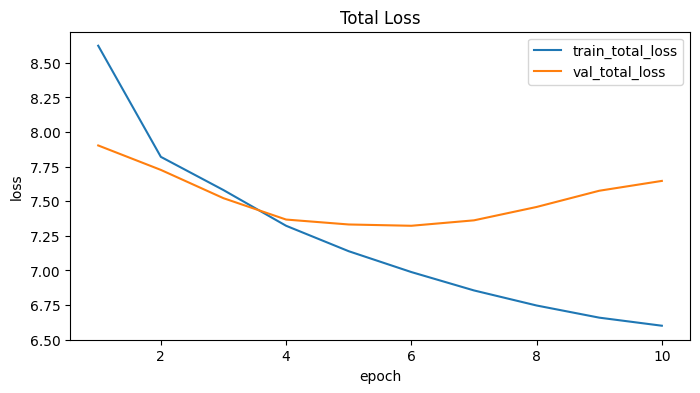

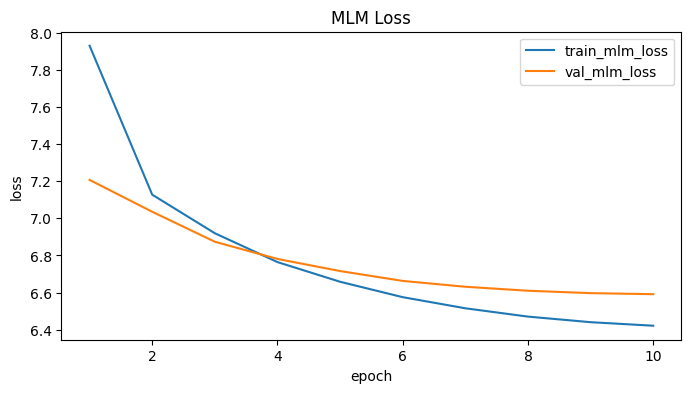

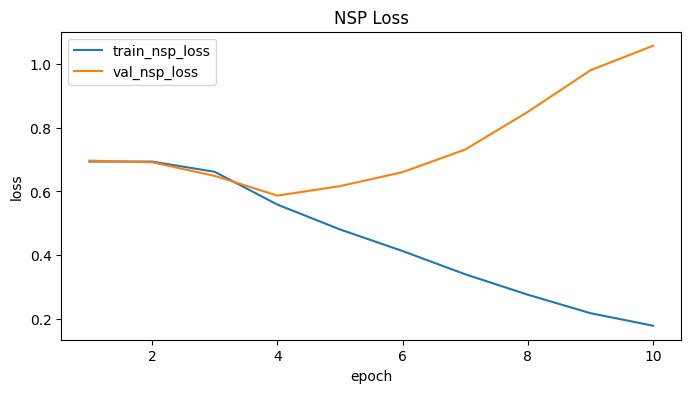

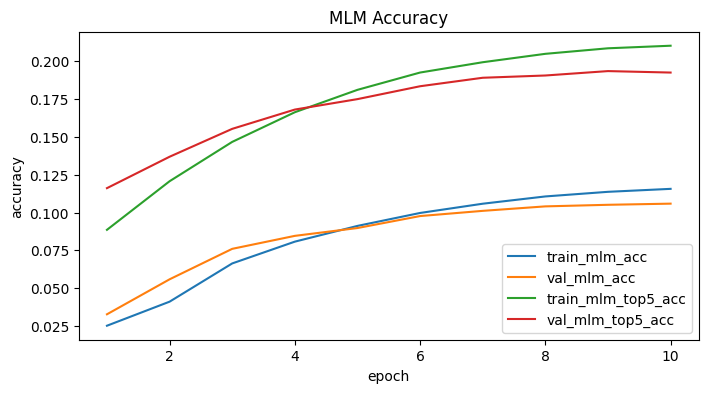

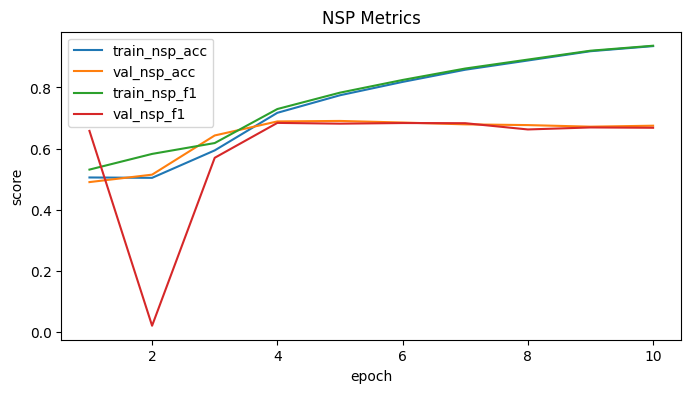

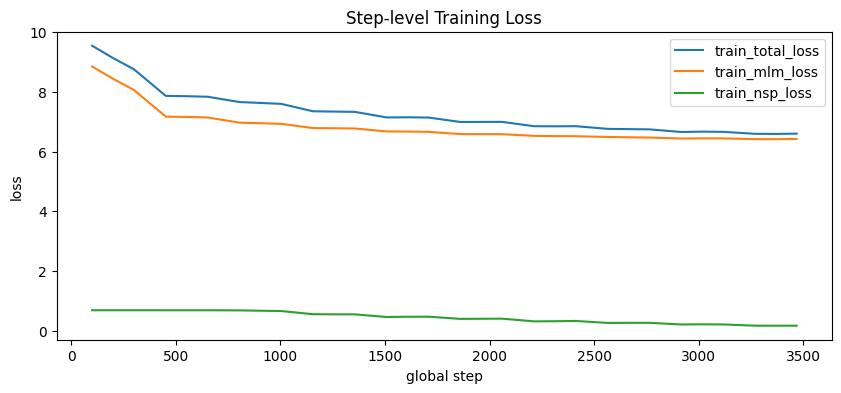

In [ ]:

# best checkpoint 재로딩 (선택)
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Loaded best checkpoint from epoch:", ckpt["epoch"], "| best val loss:", ckpt["best_val_loss"])

epochs = history["epoch"]

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_loss"], label="train_total_loss")
plt.plot(epochs, history["val_loss"], label="val_total_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Total Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_mlm_loss"], label="train_mlm_loss")
plt.plot(epochs, history["val_mlm_loss"], label="val_mlm_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("MLM Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_nsp_loss"], label="train_nsp_loss")
plt.plot(epochs, history["val_nsp_loss"], label="val_nsp_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("NSP Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_mlm_acc"], label="train_mlm_acc")
plt.plot(epochs, history["val_mlm_acc"], label="val_mlm_acc")
plt.plot(epochs, history["train_mlm_top5_acc"], label="train_mlm_top5_acc")
plt.plot(epochs, history["val_mlm_top5_acc"], label="val_mlm_top5_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("MLM Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_nsp_acc"], label="train_nsp_acc")
plt.plot(epochs, history["val_nsp_acc"], label="val_nsp_acc")
plt.plot(epochs, history["train_nsp_f1"], label="train_nsp_f1")
plt.plot(epochs, history["val_nsp_f1"], label="val_nsp_f1")
plt.xlabel("epoch")
plt.ylabel("score")
plt.title("NSP Metrics")
plt.legend()
plt.show()

# Step-level loss 흐름 (각 epoch의 로깅 지점 연결)
step_x, step_total, step_mlm, step_nsp = [], [], [], []
global_step_offset = 0
steps_per_epoch = len(train_loader)

for epoch_idx, logs in enumerate(history["step_logs"]):
    for s, tl, ml, nl in zip(logs["step"], logs["total_loss"], logs["mlm_loss"], logs["nsp_loss"]):
        step_x.append(global_step_offset + s)
        step_total.append(tl)
        step_mlm.append(ml)
        step_nsp.append(nl)
    global_step_offset += steps_per_epoch

if step_x:
    plt.figure(figsize=(10, 4))
    plt.plot(step_x, step_total, label="train_total_loss")
    plt.plot(step_x, step_mlm, label="train_mlm_loss")
    plt.plot(step_x, step_nsp, label="train_nsp_loss")
    plt.xlabel("global step")
    plt.ylabel("loss")
    plt.title("Step-level Training Loss")
    plt.legend()
    plt.show()


**9. 정성 평가**

*   마스킹 복원 예시
*   NSP 예측 예시

In [ ]:

def decode_with_labels(input_ids, mlm_labels, tokenizer):
    # masked input + labels 를 이용해 정답 원문 시퀀스를 복원
    ref_ids = input_ids.clone()
    mask_pos = mlm_labels.ne(-100)
    ref_ids[mask_pos] = mlm_labels[mask_pos]
    return ref_ids

def pretty_decode(ids, tokenizer):
    ids = ids.tolist() if isinstance(ids, torch.Tensor) else list(ids)
    ids = [i for i in ids if i != tokenizer.pad_id]
    return tokenizer.decode(ids, skip_special=False)

@torch.no_grad()
def qualitative_mlm_examples(model, subset_dataset, tokenizer, num_examples=5):
    model.eval()
    indices = random.sample(range(len(subset_dataset)), k=min(num_examples, len(subset_dataset)))

    for idx in indices:
        item = subset_dataset[idx]
        input_ids = item["input_ids"].unsqueeze(0).to(DEVICE)
        token_type_ids = item["token_type_ids"].unsqueeze(0).to(DEVICE)
        attention_mask = item["attention_mask"].unsqueeze(0).to(DEVICE)
        mlm_labels = item["mlm_labels"]

        outputs = model(input_ids, token_type_ids, attention_mask)
        pred_ids = input_ids[0].detach().cpu().clone()
        pred_tokens = outputs["mlm_logits"][0].argmax(dim=-1).detach().cpu()

        mask_pos = mlm_labels.ne(-100)
        pred_ids[mask_pos] = pred_tokens[mask_pos]
        ref_ids = decode_with_labels(item["input_ids"], mlm_labels, tokenizer)

        print("=" * 120)
        print("[Corrupted Input]")
        print(pretty_decode(item["input_ids"], tokenizer))
        print("\n[Restored Prediction]")
        print(pretty_decode(pred_ids, tokenizer))
        print("\n[Reference]")
        print(pretty_decode(ref_ids, tokenizer))

        positions = torch.where(mask_pos)[0].tolist()[:5]
        for pos in positions:
            top5 = outputs["mlm_logits"][0, pos].topk(5).indices.detach().cpu().tolist()
            print(f"  - pos={pos:3d} | gold={tokenizer.id_to_piece(int(mlm_labels[pos]))} | top5={[tokenizer.id_to_piece(t) for t in top5]}")

@torch.no_grad()
def qualitative_nsp_examples(model, subset_dataset, tokenizer, num_examples=5):
    model.eval()
    indices = random.sample(range(len(subset_dataset)), k=min(num_examples, len(subset_dataset)))

    for idx in indices:
        item = subset_dataset[idx]
        input_ids = item["input_ids"].unsqueeze(0).to(DEVICE)
        token_type_ids = item["token_type_ids"].unsqueeze(0).to(DEVICE)
        attention_mask = item["attention_mask"].unsqueeze(0).to(DEVICE)
        nsp_label = int(item["nsp_labels"].item())

        outputs = model(input_ids, token_type_ids, attention_mask)
        pred = int(outputs["nsp_logits"].argmax(dim=-1).item())
        probs = torch.softmax(outputs["nsp_logits"], dim=-1)[0].detach().cpu().tolist()

        print("=" * 120)
        print("[Input]")
        print(pretty_decode(item["input_ids"], tokenizer))
        print(f"\nNSP gold={nsp_label} | pred={pred} | prob_false={probs[0]:.4f} | prob_true={probs[1]:.4f}")

print("=== Qualitative MLM examples ===")
qualitative_mlm_examples(model, val_dataset, tokenizer, num_examples=5)

print("\n=== Qualitative NSP examples ===")
qualitative_nsp_examples(model, val_dataset, tokenizer, num_examples=5)


=== Qualitative MLM examples ===
[Corrupted Input]
[CLS] 두드[MASK]소는 경상[MASK] 사투리[MASK] 정감이 느껴지면서,[MASK]원을 두드리면 언제든지 들어주고 해결해 주는 공간이라는 의미의[MASK]광역시[MASK] 민원 서비스이다.[SEP] 개발[MASK] 참여한 각국의 기업은 다음과 같다.[SEP]

[Restored Prediction]
[CLS] 두드은소는 경상, 사투리, 정감이 느껴지면서,,원을 두드리면 언제든지 들어주고 해결해 주는 공간이라는 있다의의광역시의 민원 서비스이다.[SEP] 개발의 참여한 각국의 기업은 다음과 같다.[SEP]

[Reference]
[CLS] 두드리소는 경상도 사투리의 정감이 느껴지면서, 민원을 두드리면 언제든지 들어주고 해결해 주는 공간이라는 의미의 대구광역시의 민원 서비스이다.[SEP] 개발에 참여한 각국의 기업은 다음과 같다.[SEP]
  - pos=  3 | gold=리 | top5=['은', '의', '년', '▁', '는']
  - pos=  8 | gold=도 | top5=[',', '의', '▁', '는', '은']
  - pos= 12 | gold=의 | top5=[',', '의', '▁', '이', '을']
  - pos= 21 | gold=▁민 | top5=[',', '의', '▁', '에', '을']
  - pos= 39 | gold=▁의미 | top5=['▁있다', '에', '고', '소', ',']
[Corrupted Input]
[CLS] 밀러의 실험에선 L[MASK]형 아미노산[MASK] D-형 아 아시아노산 두 가지가 생성되었다줍[SEP] 통계설자들은 D-형 아미노산은 죽은 생명체[MASK] L-형 아미노[MASK]이 변화하여 서로 분자의 수가 같아지는데 밀[MASK]의 실험에서도 L[MASK]형[MASK] D-형의 아미[MASK] 오페라이 발견[MASK]므로 생물로서의 역할을 할 수가 없다라고 주장한다.[SEP]

[Restored P

**10. 정량 평가 + BERTScore(보조 지표)**

*   MLM loss
*   NSP loss
*   MLM accuracy
*   MLM top-k accuracy
*   NSP accuracy/F1
*   보조 지표로 BERTScore(복원 문장 기준) 추가  


eval:   0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_787/1045606151.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.USE_AMP):


Validation metrics
            loss: 7.323136
        mlm_loss: 6.662765
        nsp_loss: 0.660371
         mlm_acc: 0.097665
    mlm_top5_acc: 0.183431
         nsp_acc: 0.685200
   nsp_precision: 0.673534
      nsp_recall: 0.693878
          nsp_f1: 0.683554


NSP confusion matrix:   0%|          | 0/40 [00:00<?, ?it/s]

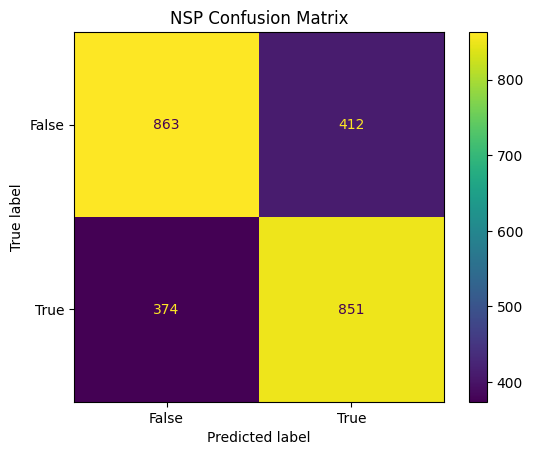

MLM Perplexity (approx): 782.7120


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 0.40 seconds, 318.47 sentences/sec
[BERTScore - Mask-only restoration] P=0.8138 | R=0.7998 | F1=0.8066


In [ ]:

@torch.no_grad()
def collect_restoration_texts(model, subset_dataset, tokenizer, max_samples=128):
    model.eval()
    n = min(max_samples, len(subset_dataset))
    indices = random.sample(range(len(subset_dataset)), k=n)

    refs_full, preds_full = [], []
    refs_mask_only, preds_mask_only = [], []

    for idx in tqdm(indices, desc="Collecting restoration texts"):
        item = subset_dataset[idx]
        input_ids = item["input_ids"].unsqueeze(0).to(DEVICE)
        token_type_ids = item["token_type_ids"].unsqueeze(0).to(DEVICE)
        attention_mask = item["attention_mask"].unsqueeze(0).to(DEVICE)
        mlm_labels = item["mlm_labels"]

        outputs = model(input_ids, token_type_ids, attention_mask)
        pred_token_ids = outputs["mlm_logits"][0].argmax(dim=-1).detach().cpu()

        corrupted = item["input_ids"].clone()
        pred_ids = corrupted.clone()
        mask_pos = mlm_labels.ne(-100)
        pred_ids[mask_pos] = pred_token_ids[mask_pos]
        ref_ids = decode_with_labels(corrupted, mlm_labels, tokenizer)

        ref_full = tokenizer.decode([int(i) for i in ref_ids.tolist() if int(i) != tokenizer.pad_id], skip_special=True)
        pred_full = tokenizer.decode([int(i) for i in pred_ids.tolist() if int(i) != tokenizer.pad_id], skip_special=True)

        # masked-only 복원 성능도 같이 봄(subword 단위라 해석은 보조적)
        ref_mask = tokenizer.decode([int(i) for i in mlm_labels[mask_pos].tolist()], skip_special=True)
        pred_mask = tokenizer.decode([int(i) for i in pred_token_ids[mask_pos].tolist()], skip_special=True)

        if ref_full.strip() and pred_full.strip():
            refs_full.append(ref_full)
            preds_full.append(pred_full)

        if ref_mask.strip() and pred_mask.strip():
            refs_mask_only.append(ref_mask)
            preds_mask_only.append(pred_mask)

    return refs_full, preds_full, refs_mask_only, preds_mask_only

# 기본 정량 평가 (loss/acc/f1) - validation set
val_metrics = run_epoch(model, val_loader, train=False)
print("Validation metrics")
for k, v in val_metrics.items():
    if k == "step_logs":
        continue
    print(f"{k:>16}: {v:.6f}")

# NSP confusion matrix
all_nsp_preds, all_nsp_gold = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="NSP confusion matrix"):
        outputs = model(
            batch["input_ids"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
        )
        preds = outputs["nsp_logits"].argmax(dim=-1).detach().cpu().numpy()
        gold = batch["nsp_labels"].numpy()

        all_nsp_preds.extend(preds.tolist())
        all_nsp_gold.extend(gold.tolist())

cm = confusion_matrix(all_nsp_gold, all_nsp_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["False", "True"])
disp.plot()
plt.title("NSP Confusion Matrix")
plt.show()

# MLM Perplexity (참고용)
mlm_ppl = math.exp(min(20, val_metrics["mlm_loss"]))  # overflow 방지용 min
print(f"MLM Perplexity (approx): {mlm_ppl:.4f}")

# BERTScore (보조 지표)
# BERTScore는 원래 생성형 텍스트 평가용이므로, MLM/NSP pretrain의 '주지표'가 아니라 '보조지표'로 해석하는 것이 적절
refs_full, preds_full, refs_mask_only, preds_mask_only = collect_restoration_texts(
    model, val_dataset, tokenizer, max_samples=CFG.BERTSCORE_MAX_SAMPLES
)

try:
    from bert_score import score as bertscore_score

    if refs_full and preds_full:
        P, R, F1 = bertscore_score(
            preds_full,
            refs_full,
            model_type=CFG.BERTSCORE_MODEL,
            lang="ko",
            device=DEVICE,
            verbose=True,
        )
        print(f"[BERTScore - Full restoration] P={P.mean().item():.4f} | R={R.mean().item():.4f} | F1={F1.mean().item():.4f}")

    if refs_mask_only and preds_mask_only:
        Pm, Rm, F1m = bertscore_score(
            preds_mask_only,
            refs_mask_only,
            model_type=CFG.BERTSCORE_MODEL,
            lang="ko",
            device=DEVICE,
            verbose=True,
        )
        print(f"[BERTScore - Mask-only restoration] P={Pm.mean().item():.4f} | R={Rm.mean().item():.4f} | F1={F1m.mean().item():.4f}")

except Exception as e:
    print("BERTScore 계산 중 오류가 발생했습니다.")
    print(e)
    print("인터넷 연결/모델 다운로드 문제일 수 있으므로, 주평가 지표는 MLM/NSP loss/accuracy/F1을 우선 사용하세요.")


**11. 모델, 토크나이저, 메타데이터 저장**

In [ ]:

# 최종 아티팩트 저장
artifact_dir = BASE_DIR / CFG.MODEL_DIR
artifact_dir.mkdir(parents=True, exist_ok=True)

final_model_path = artifact_dir / "mini_bert_pretrain_final.pt"
tokenizer_copy_path = artifact_dir / f"{CFG.TOKENIZER_PREFIX}.model"
manifest_copy_path = artifact_dir / "dataset_manifest.json"
config_copy_path = artifact_dir / "mini_bert_config.json"

torch.save({
    "model_state_dict": model.state_dict(),
    "config": dict(CFG),
}, final_model_path)

# tokenizer / config / manifest 복사 저장
import shutil
shutil.copy2(sp_model_path, tokenizer_copy_path)
shutil.copy2(manifest_path, manifest_copy_path)
CFG.save_json(config_copy_path)

print("Saved model:", final_model_path)
print("Saved tokenizer:", tokenizer_copy_path)
print("Saved manifest:", manifest_copy_path)
print("Saved config:", config_copy_path)


Saved model: /content/mini_bert_project/artifacts/mini_bert_pretrain_final.pt
Saved tokenizer: /content/mini_bert_project/artifacts/spm_bert_ko_8k.model
Saved manifest: /content/mini_bert_project/artifacts/dataset_manifest.json
Saved config: /content/mini_bert_project/artifacts/mini_bert_config.json


**결과분석**

*   학습 결과를 보면, validation total loss는 초반부터 epoch 6까지 감소하였고, best validation loss는 7.3231에서 기록되었다. 특히, MLM loss는 전체 학습 구간에서 비교적 안정적으로 감소하였으며, masked token accuracy 역시 0.0328에서 0.1059까지 증가하였다. 절대값만 보면 높지 않은 정확도처럼 보일 수 있으나, 8000개 vocabulary에 대한 서브워드 복원 문제라는 점과 모델 규모가 1M 수준이라는 점을 고려하면 의미 있는 개선이라고 할 수 있다. 또한 mlm_top5_acc = 0.1834(정답이 top-5 후보 안에 들어오는 비율이 약 18% 수준)이라는 점에서 모델이 완전히 무작위로 예측하는 것은 아니었다.
*   NSP 측면에서는 validation accuracy가 0.49에서 0.6852까지 상승하였고, F1도 0.6836을 기록하였다. 이는 문장쌍의 연속성 여부를 학습했음을 보여준다. 반면에, train NSP loss는 계속 감소한 반면 validation NSP loss는 후반부에 다시 증가하였다. 특히 epoch 7 이후 validation total loss가 상승하고, epoch 10에서는 validation NSP loss가 1.0560까지 증가하였다. 반면, train NSP accuracy는 0.9356까지 높아졌다. 이는 NSP head가 학습 데이터에는 지나치게 맞춰지고, validation에서는 일반화 성능이 떨어지는 과적합 양상으로 볼 수 있다.
*   복원 예시를 보면 조사, 연결 표현, 쉼표와 같은 빈도가 높은 토큰은 어느 정도 복원하지만, ‘대구광역시’, ‘문민정부’, ‘OECD’, ‘온전히’, ‘길이’와 같은 의미 중심 토큰이나 고유명사는 자주 틀린다. 즉, 이 모델은 한국어 문장의 표면적 패턴과 문법적 구조는 일정 부분 학습했지만, 의미 중심 정보 복원 능력은 제한적임을 알 수 있다.
*   BERTScore를 통해 복원 문장 품질을 보조적으로 점검한 결과, Full restoration 기준 F1은 0.9533, Mask-only restoration 기준 F1은 0.8066으로 나타났다. MLM 중심의 문맥 학습이 가능함을 보여주었다.





**프로젝트의 한계점 및 보완점**

*   NSP accuracy는 향상되었지만 validation NSP loss는 후반에 악화된 것으로 보아 NSP가 실제 언어에 대한 이해를 충분히 못하였거나, negative pair 생성 방식이 지나치게 쉬워졌다가 어려운 단계를 해결하지 못했을 가능성이 있다.
*   결과를 보면 epoch 7 이후에 validation 성능이 악화되므로, 10 epoch 고정보다 조기 종료가 더 합리적일 수 있다.
*   Teacher로 대규모 한국어 BERT나 multilingual encoder를 두고, Student로 mini BERT를 distillation(https://dodonam.tistory.com/364#google_vignette)하면 작은 모델의 성능을 더 효율적으로 상승시킬 수 있으므로 판단된다.



**회고**

*   BERT pretraining이 반드시 큰 모델과 대규모 장비에서만 가능한 것은 아니였으며, 제한된 환경에서도 토크나이저 학습, MLM/NSP 데이터셋 생성, mini BERT 구현, 학습, 시각화, 정량·정성 평가까지 한 흐름으로 재현할 수 있었다는 점은 의미가 있었다.
*   이번 실험은 loss가 낮아야 성공이 아니라, 모델 목적에 맞는 지표를 해석해야 한다는 점을 보여주었는데 초기에는 MLM accuracy가 낮아 보여도, loss 감소 추세와 top-5 accuracy 상승, NSP accuracy 상승, 정성 예시 개선을 함께 보면 모델이 실제로 학습되고 있음을 알 수 있었다.
*   BERT는 말을 잘하는 모델이 아니라 문맥을 잘 표현하고 해석을 잘하는 모델이라는 점이다. 정성 평가에서 문장이 자연스럽지 않게 복원되는 모습을 보고 성능이 낮다고 결론내리기 쉽지만, encoder 기반 pretraining의 목적은 생성이 아니라 representation 학습이라는 것이다.

